In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import os
from pathlib import Path
import glob
import json
import numpy as np
import anndata as ad
import pandas as pd
import matplotlib.pyplot as plt

import sys
sys.path.append("/code")
import bg_spatial_plots.plot_spatial_histograms as histplot
from plot_confusion_matrix import plot_confusion_matrix

%matplotlib inline

# Plotting params

In [3]:
output_fig_dir = '/scratch/mat_paper_figures/for_YF_astro'
os.makedirs(output_fig_dir, exist_ok=True)

plt.rcParams.update({'font.size': 6})

# to get text as text and not paths in Illustrator
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['svg.fonttype'] = 'none'

# this can mess with some plots, use cautiously
# plt.rcParams['figure.constrained_layout.use'] = True

# Astro subgroup params

In [4]:
subgroup_cluster_dict = {
    'GM STR': ['h-7', 'h-14', 'h-31'],
    'GM exSTR': [
        'h-145',
        'h-146',
        'h-149',
        'h-150',
        'h-152',
        'h-159',
        'h-160',
        'h-450',
        'h-452'
    ],
    'WM': ['h-28', 'h-227', 'h-230', 'h-231', 'h-472', 'h-479', 'h-485'],
    'Mixed': ['h-143', 'h-232']
}

# # replace h- with Human-
# subgroup_cluster_dict = {k: [c.replace('h-', 'Human-') for c in v] for k, v in subgroup_cluster_dict.items()}
# subgroup_cluster_dict

# invert the dictionary to get cluster to subgroup mapping
cluster_subgroup_dict = {c: k for k, v in subgroup_cluster_dict.items() for c in v}
cluster_subgroup_dict

{'h-7': 'GM STR',
 'h-14': 'GM STR',
 'h-31': 'GM STR',
 'h-145': 'GM exSTR',
 'h-146': 'GM exSTR',
 'h-149': 'GM exSTR',
 'h-150': 'GM exSTR',
 'h-152': 'GM exSTR',
 'h-159': 'GM exSTR',
 'h-160': 'GM exSTR',
 'h-450': 'GM exSTR',
 'h-452': 'GM exSTR',
 'h-28': 'WM',
 'h-227': 'WM',
 'h-230': 'WM',
 'h-231': 'WM',
 'h-472': 'WM',
 'h-479': 'WM',
 'h-485': 'WM',
 'h-143': 'Mixed',
 'h-232': 'Mixed'}

# Load data

In [5]:
adata_spatial = ad.read_h5ad('/data/cirro_files_hmba_human_20250922/hmba_release_format_human_cirro_h5ad_20250922.h5ad')
adata_spatial

AnnData object with n_obs × n_vars = 6992128 × 314
    obs: 'x', 'y', 'brain_section_label', 'brain_section_barcode', 'slab', 'block', 'set', 'z_order', 'total_counts', 'total_counts_genes', 'n_genes_by_counts', 'total_counts_Blank', 'pct_counts_Blank', 'genes_filter', 'counts_filter', 'blanks_filter', 'qc_pass', 'doublets_filter', 'qc_pass_and_singlet', 'doublet_singlet_score_diff', 'doublet_diff_threshold', 'hierarchy_consistent', 'Neighborhood', 'Neighborhood_bootstrapping_probability', 'Neighborhood_correlation_coefficient', 'Class', 'Class_bootstrapping_probability', 'Class_correlation_coefficient', 'Subclass', 'Subclass_bootstrapping_probability', 'Subclass_correlation_coefficient', 'Group', 'Group_bootstrapping_probability', 'Group_correlation_coefficient', 'cluster_id', 'cluster_id_bootstrapping_probability', 'cluster_id_correlation_coefficient', 'Neighborhood_entropy', 'Class_entropy', 'Subclass_entropy', 'Group_entropy', 'cluster_id_entropy', 'STAligner_mclust_res_10_knn_15',

In [6]:
adata_spatial_astro = adata_spatial[adata_spatial.obs['Group'] == 'Astrocyte', :].copy()
# del adata_spatial
adata_spatial_astro

AnnData object with n_obs × n_vars = 641913 × 314
    obs: 'x', 'y', 'brain_section_label', 'brain_section_barcode', 'slab', 'block', 'set', 'z_order', 'total_counts', 'total_counts_genes', 'n_genes_by_counts', 'total_counts_Blank', 'pct_counts_Blank', 'genes_filter', 'counts_filter', 'blanks_filter', 'qc_pass', 'doublets_filter', 'qc_pass_and_singlet', 'doublet_singlet_score_diff', 'doublet_diff_threshold', 'hierarchy_consistent', 'Neighborhood', 'Neighborhood_bootstrapping_probability', 'Neighborhood_correlation_coefficient', 'Class', 'Class_bootstrapping_probability', 'Class_correlation_coefficient', 'Subclass', 'Subclass_bootstrapping_probability', 'Subclass_correlation_coefficient', 'Group', 'Group_bootstrapping_probability', 'Group_correlation_coefficient', 'cluster_id', 'cluster_id_bootstrapping_probability', 'cluster_id_correlation_coefficient', 'Neighborhood_entropy', 'Class_entropy', 'Subclass_entropy', 'Group_entropy', 'cluster_id_entropy', 'STAligner_mclust_res_10_knn_15', 

In [7]:
# snRNA-seq data
adata_rnaseq_selfmap = ad.read_h5ad(
    '/data/human_snRNAseq_astrocyte_MMC_results_with_Astro_SubGroups/HMBA_human_Astro_3subGroups_mmc_mapped-withAstroSubGroups.h5ad',
)
adata_rnaseq_selfmap

AnnData object with n_obs × n_vars = 134124 × 36601
    obs: 'Neighborhood', 'Class', 'Subclass', 'Group', 'Cluster', 'donor_id', 'anatomical_region', 'anatomical_region_merged', 'anatomical_region_ontology_term_id', 'self_reported_sex', 'self_reported_sex_ontology_term_id', 'self_reported_ethnicity', 'self_reported_ethnicity_ontology_term_id', 'disease', 'disease_ontology_term_id', 'suspension_type', 'is_primary_data', 'atac_confidently_mapped_read_pairs', 'atac_fraction_of_genome_in_peaks', 'atac_fraction_of_high_quality_fragments_in_cells', 'atac_fraction_of_high_quality_fragments_overlapping_tss', 'atac_fraction_of_high_quality_fragments_overlapping_peaks', 'atac_fraction_of_transposition_events_in_peaks_in_cells', 'atac_mean_raw_read_pairs_per_cell', 'atac_median_high_quality_fragments_per_cell', 'atac_non_nuclear_read_pairs', 'atac_number_of_peaks', 'atac_percent_duplicates', 'atac_q30_bases_in_barcode', 'atac_q30_bases_in_read_1', 'atac_q30_bases_in_read_2', 'atac_q30_bases_in_s

In [8]:
# replace('Human-', 'h-')
adata_spatial_astro.obs['Cluster'] = adata_spatial_astro.obs['Cluster'].str.replace('Human-', 'h-')
adata_spatial_astro.obs['cluster_id'] = adata_spatial_astro.obs['cluster_id'].str.replace('Human-', 'h-')

In [9]:
# add in subgroup labels
adata_spatial_astro.obs['SubGroup'] = adata_spatial_astro.obs['cluster_id'].map(cluster_subgroup_dict)

In [10]:
adata_spatial_astro.obs['SubGroup']

cell_label
1321115602_26       GM STR
1321115602_32       GM STR
1321115602_39        Mixed
1321115602_41       GM STR
1321115602_44       GM STR
                     ...  
1384732991_84452        WM
1384732991_84453        WM
1384732991_84461        WM
1384732991_84472        WM
1384732991_84491        WM
Name: SubGroup, Length: 641913, dtype: object

In [11]:
adata_spatial_astro.obs['SubGroup'].value_counts(dropna=False)

SubGroup
GM STR      289122
WM          195828
GM exSTR    112857
Mixed        44106
Name: count, dtype: int64

# Read in marker gene lists

In [12]:
cluster_degs_overlap = pd.read_csv('/scratch/astrocytes/Cluster_level_DEGs_overlap-wilcoxon-DEseq2.csv')

# replace Human- with h-
cluster_degs_overlap['cluster'] = cluster_degs_overlap['cluster'].str.replace('Human-', 'h-')
cluster_degs_overlap

,cluster,gene,scanpy_wilcoxon_scores,scanpy_wilcoxon_logfoldchanges,scanpy_wilcoxon_pvals,scanpy_wilcoxon_pvals_adj,scanpy_wilcoxon_pct_nz_group,scanpy_wilcoxon_pct_nz_reference,cluster_x,subgroup_x,pseudobulk_DESeq2_baseMean,pseudobulk_DESeq2_logFC_deseq,pseudobulk_DESeq2_lfcSE,pseudobulk_DESeq2_stat,pseudobulk_DESeq2_pvalue,pseudobulk_DESeq2_padj,subgroup_y,cluster_y,pseudobulk_DESeq2_n_donors_used
0,h-227,RBFOX1,15.902266,4.971837,6.111265e-57,2.236784e-52,0.926667,0.558033,Human-227,WM,1112.718682,2.982659,0.340272,8.765506,1.859400e-18,7.454007e-16,WM,Human-227,5
1,h-227,KCNIP4,15.389722,5.641509,1.918558e-53,3.511057e-49,0.880000,0.415281,Human-227,WM,1010.246937,3.938723,0.493815,7.976105,1.510239e-15,4.288449e-13,WM,Human-227,5
2,h-227,CSMD1,14.092140,5.260199,4.244972e-45,5.179007e-41,0.813333,0.368671,Human-227,WM,695.208772,3.900162,0.340051,11.469329,1.881129e-30,5.494241e-27,WM,Human-227,5
3,h-227,RYR2,13.767401,5.916244,4.003591e-43,3.663386e-39,0.766667,0.205630,Human-227,WM,402.595248,4.192321,0.479019,8.751890,2.098083e-18,8.249096e-16,WM,Human-227,5
4,h-227,RIMS2,13.633246,5.904738,2.540229e-42,1.859498e-38,0.740000,0.189545,Human-227,WM,306.955209,4.097118,0.379059,10.808669,3.131803e-27,5.335809e-24,WM,Human-227,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4530,h-450,LINC01497,3.130130,1.052096,1.747292e-03,3.429096e-02,0.136640,0.074140,Human-450,GM exSTR,36.915858,0.584487,0.165629,3.528895,4.172986e-04,1.445886e-02,GM exSTR,Human-450,10
4531,h-450,BASP1,3.048070,1.206986,2.303161e-03,4.261779e-02,0.118421,0.058531,Human-450,GM exSTR,25.358829,0.760851,0.193988,3.922159,8.775899e-05,4.174264e-03,GM exSTR,Human-450,10
4532,h-450,PXDNL,3.024501,0.986999,2.490441e-03,4.565687e-02,0.138664,0.078278,Human-450,GM exSTR,36.020310,0.626334,0.205344,3.050175,2.287083e-03,4.974821e-02,GM exSTR,Human-450,10
4533,h-146,AL356488.2,10.478546,5.062348,1.083968e-25,1.239822e-22,0.564103,0.088061,Human-146,GM exSTR,60.834712,2.387334,0.494713,4.825694,1.395166e-06,3.999242e-03,GM exSTR,Human-146,4


In [13]:
# filter down to rows where the gene is in the spatial adata
cluster_degs_overlap = cluster_degs_overlap[cluster_degs_overlap['gene'].isin(adata_spatial_astro.var_names)]
cluster_degs_overlap

,cluster,gene,scanpy_wilcoxon_scores,scanpy_wilcoxon_logfoldchanges,scanpy_wilcoxon_pvals,scanpy_wilcoxon_pvals_adj,scanpy_wilcoxon_pct_nz_group,scanpy_wilcoxon_pct_nz_reference,cluster_x,subgroup_x,pseudobulk_DESeq2_baseMean,pseudobulk_DESeq2_logFC_deseq,pseudobulk_DESeq2_lfcSE,pseudobulk_DESeq2_stat,pseudobulk_DESeq2_pvalue,pseudobulk_DESeq2_padj,subgroup_y,cluster_y,pseudobulk_DESeq2_n_donors_used
8,h-227,PDE10A,12.881207,5.734771,5.742993e-38,2.335548e-34,0.720000,0.185889,Human-227,WM,279.365092,3.638554,0.367528,9.900071,4.159784e-23,3.543616e-20,WM,Human-227,5
18,h-227,DCC,10.824830,5.113218,2.625666e-27,5.057999e-24,0.613333,0.139828,Human-227,WM,174.105019,3.431730,0.434347,7.900897,2.769028e-15,6.989231e-13,WM,Human-227,5
39,h-227,SGCZ,8.436878,3.945762,3.259248e-17,2.982293e-14,0.533333,0.177664,Human-227,WM,284.898866,3.666516,0.275898,13.289378,2.667863e-40,2.727223e-36,WM,Human-227,5
60,h-227,ANO3,7.121983,4.330012,1.063851e-12,6.084067e-10,0.400000,0.068178,Human-227,WM,82.918491,3.342663,0.577677,5.786386,7.191693e-09,5.904986e-07,WM,Human-227,5
101,h-227,CNTN5,6.036968,2.779124,1.570369e-09,4.684758e-07,0.480000,0.229940,Human-227,WM,238.761464,2.123800,0.466248,4.555085,5.236451e-06,2.507242e-04,WM,Human-227,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4458,h-450,OTX2-AS1,7.749454,1.848854,9.228816e-15,1.431288e-12,0.273279,0.122384,Human-450,GM exSTR,130.945246,1.209910,0.285713,4.234701,2.288557e-05,1.514121e-03,GM exSTR,Human-450,10
4466,h-450,PLD5,6.515506,1.575793,7.244490e-11,7.532829e-09,0.251012,0.126759,Human-450,GM exSTR,76.742992,1.033936,0.205717,5.026006,5.008012e-07,6.765866e-05,GM exSTR,Human-450,10
4468,h-450,RNF144B,6.452448,1.422937,1.100575e-10,1.122066e-08,0.272267,0.141658,Human-450,GM exSTR,69.512972,0.558472,0.138934,4.019693,5.827391e-05,3.091979e-03,GM exSTR,Human-450,10
4490,h-450,DCC,5.361281,1.124867,8.263397e-08,5.278335e-06,0.284413,0.179615,Human-450,GM exSTR,108.515159,0.681101,0.188294,3.617225,2.977779e-04,1.098022e-02,GM exSTR,Human-450,10


In [14]:
# start with the 'GM STR' subgroup clusters
gm_str_degs = cluster_degs_overlap[cluster_degs_overlap['subgroup_y'] == 'GM STR'].copy().reset_index(drop=True)
gm_str_degs

,cluster,gene,scanpy_wilcoxon_scores,scanpy_wilcoxon_logfoldchanges,scanpy_wilcoxon_pvals,scanpy_wilcoxon_pvals_adj,scanpy_wilcoxon_pct_nz_group,scanpy_wilcoxon_pct_nz_reference,cluster_x,subgroup_x,pseudobulk_DESeq2_baseMean,pseudobulk_DESeq2_logFC_deseq,pseudobulk_DESeq2_lfcSE,pseudobulk_DESeq2_stat,pseudobulk_DESeq2_pvalue,pseudobulk_DESeq2_padj,subgroup_y,cluster_y,pseudobulk_DESeq2_n_donors_used
0,h-31,MT1X,17.719460,3.280859,2.967502e-70,2.413634e-67,0.679637,0.337065,Human-31,GM STR,204.078288,1.338504,0.224303,5.967396,2.410701e-09,2.217717e-07,GM STR,Human-31,8
1,h-31,CD44,14.549906,4.949203,5.848350e-48,1.726254e-45,0.376135,0.047504,Human-31,GM STR,233.431780,4.514168,0.422772,10.677556,1.296403e-26,2.115115e-23,GM STR,Human-31,8
2,h-31,FAM189A2,11.640197,1.193772,2.574217e-31,4.282677e-29,0.878080,0.853253,Human-31,GM STR,1899.755868,0.522981,0.115962,4.509931,6.484885e-06,2.167538e-04,GM STR,Human-31,8
3,h-31,EMP1,11.411416,3.265221,3.667106e-30,5.886832e-28,0.367056,0.129803,Human-31,GM STR,239.259425,3.051396,0.456695,6.681469,2.365596e-11,3.823643e-09,GM STR,Human-31,8
4,h-31,UBASH3B,11.363767,3.771053,6.335282e-30,9.951831e-28,0.316472,0.064448,Human-31,GM STR,97.042270,3.066019,0.335654,9.134474,6.572535e-20,5.412952e-17,GM STR,Human-31,8
5,h-31,CXCL14,10.514477,2.075170,7.409122e-26,9.448825e-24,0.530480,0.371256,Human-31,GM STR,299.055913,1.120584,0.222321,5.040377,4.646161e-07,2.269925e-05,GM STR,Human-31,8
6,h-31,MT1E,10.438041,1.727365,1.662059e-25,2.048249e-23,0.665370,0.485325,Human-31,GM STR,203.675991,0.518929,0.155343,3.340539,8.361596e-04,1.186331e-02,GM STR,Human-31,8
7,h-31,CA2,10.204859,2.098792,1.885954e-24,2.177534e-22,0.447471,0.249924,Human-31,GM STR,127.281366,1.513186,0.259765,5.825209,5.704130e-09,4.546218e-07,GM STR,Human-31,8
8,h-31,VCAN,9.312202,2.040892,1.252098e-20,1.154359e-18,0.409857,0.213918,Human-31,GM STR,117.065464,1.309512,0.162983,8.034645,9.385027e-16,3.987788e-13,GM STR,Human-31,8
9,h-31,IL1R1,8.634951,3.769678,5.875220e-18,4.424669e-16,0.229572,0.031770,Human-31,GM STR,33.479799,2.644928,0.342274,7.727512,1.096689e-14,4.214941e-12,GM STR,Human-31,8


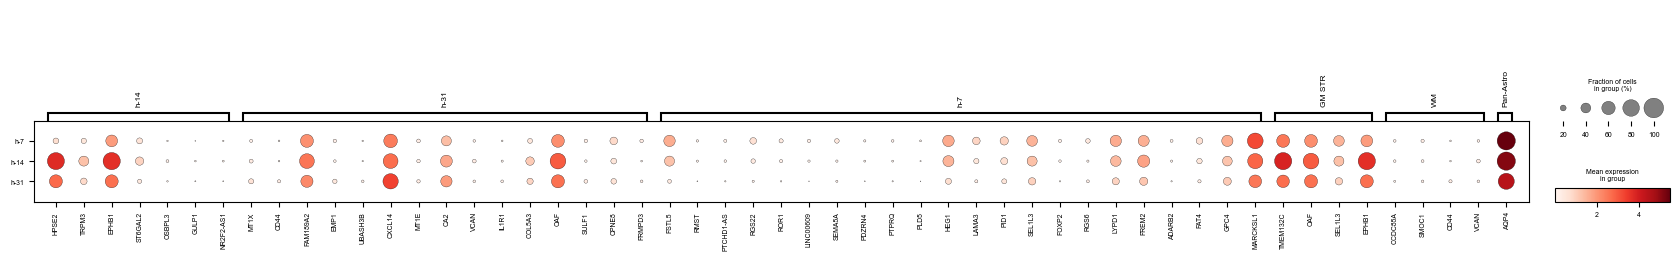

In [15]:
import scanpy as sc

adata_gm_str = adata_spatial_astro[adata_spatial_astro.obs['SubGroup'] == 'GM STR', :].copy()
# cluster: multiple gene values
markers = gm_str_degs.groupby('cluster')['gene'].apply(list).to_dict()
markers['GM STR'] = ['TMEM132C', 'OAF', 'SEL1L3', 'EPHB1']
markers['WM'] = ['CCDC85A', 'SMOC1', 'CD44', 'VCAN']
markers['Pan-Astro'] = ['AQP4']

sc.pl.dotplot(adata_gm_str, markers, groupby='Cluster', layer='log2cpt')

## SubGroup level & Pan-Astro markers

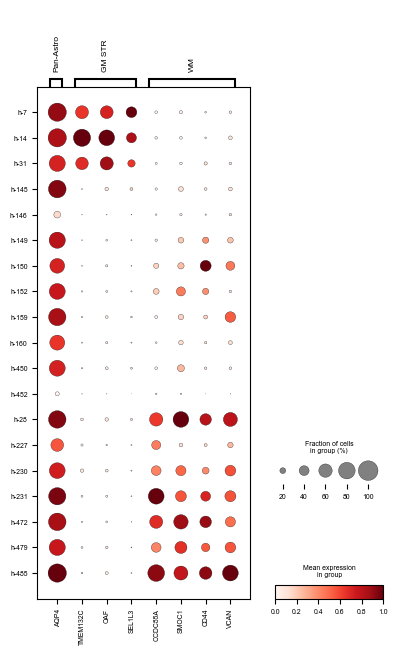

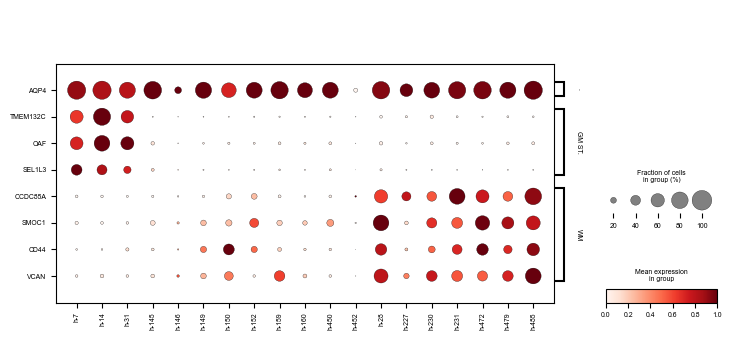

In [31]:
markers_curated = {}
markers_curated['Pan-Astro'] = ['AQP4']
markers_curated['GM STR'] = ['TMEM132C', 'OAF', 'SEL1L3']  # also 14 specific:  'EPHB1'
# markers_curated['GM exSTR'] = ['RGS6', 'COL5A3', 'CDH23', ] # all except for h-452 ... which also weirdly doesn't express AQP4
markers_curated['WM'] = ['CCDC85A', 'SMOC1', 'CD44', 'VCAN']

adata_astro_curated = adata_spatial_astro[adata_spatial_astro.obs['SubGroup'].isin(['GM STR', 'GM exSTR', 'WM']), :].copy()
cluster_order = subgroup_cluster_dict['GM STR'] + subgroup_cluster_dict['GM exSTR'] + subgroup_cluster_dict['WM']
adata_astro_curated.obs['Cluster'] = pd.Categorical(adata_astro_curated.obs['Cluster'], categories=cluster_order, ordered=True)


dot_SubGroup = sc.pl.dotplot(
    adata_astro_curated, 
    markers_curated, 
    groupby='Cluster', 
    layer='log2cpt', 
    return_fig=True,
    standard_scale="var",
    swap_axes=False
)
plt.show()
dot_SubGroup.savefig(os.path.join(output_fig_dir, 'dotplot_astro_SubGroup_markers.png'), dpi=300)
dot_SubGroup.savefig(os.path.join(output_fig_dir, 'dotplot_astro_SubGroup_markers.pdf'))
plt.close()

dot_SubGroup = sc.pl.dotplot(
    adata_astro_curated, 
    markers_curated, 
    groupby='Cluster', 
    layer='log2cpt', 
    return_fig=True,
    standard_scale="var",
    swap_axes=True
)
plt.show()
dot_SubGroup.savefig(os.path.join(output_fig_dir, 'dotplot_astro_SubGroup_markers_swapaxes.png'), dpi=300)
dot_SubGroup.savefig(os.path.join(output_fig_dir, 'dotplot_astro_SubGroup_markers_swapaxes.pdf'))
plt.close()

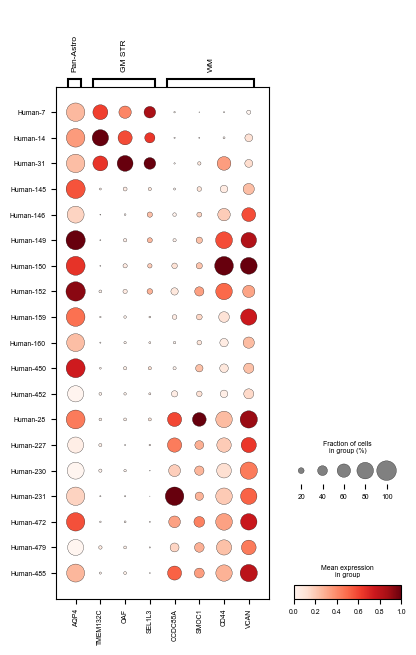

In [30]:
cluster_order_Human = [c.replace('h-', 'Human-') for c in cluster_order]
adata_rnaseq_selfmap.obs['Cluster'] = pd.Categorical(adata_rnaseq_selfmap.obs['Cluster'], categories=cluster_order_Human, ordered=True)
dot_SubGroup_rnaseq = sc.pl.dotplot(
    adata_rnaseq_selfmap, 
    markers_curated, 
    groupby='Cluster', 
    return_fig=True,
    standard_scale="var",
    swap_axes=False
)
dot_SubGroup_rnaseq.savefig(os.path.join(output_fig_dir, 'dotplot_astro_SubGroup_markers_rnaseq.png'), dpi=300)
plt.show()
dot_SubGroup_rnaseq.savefig(os.path.join(output_fig_dir, 'dotplot_astro_SubGroup_markers_rnaseq.pdf'))
plt.close()

## Cluster level markers

### GM STR clusters

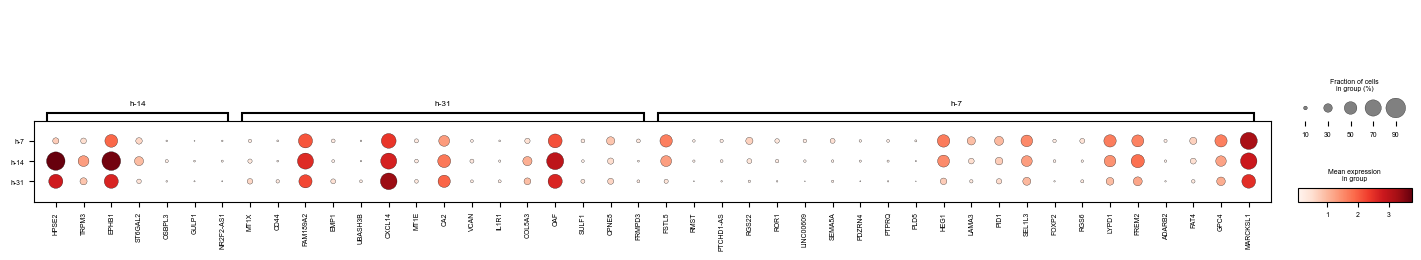

In [18]:
adata_astro_curated = adata_spatial_astro[adata_spatial_astro.obs['Group'] == 'Astrocyte', :].copy()

gm_str_degs = cluster_degs_overlap[cluster_degs_overlap['subgroup_y'] == 'GM STR'].copy().reset_index(drop=True)
markers = gm_str_degs.groupby('cluster')['gene'].apply(list).to_dict()

dot_GM_STR = sc.pl.dotplot(adata_gm_str, markers, groupby='Cluster', layer='log2cpt', return_fig=True)
dot_GM_STR.savefig(os.path.join(output_fig_dir, 'dotplot_GM_STR_markers.png'), dpi=300)
plt.show()
dot_GM_STR.savefig(os.path.join(output_fig_dir, 'dotplot_GM_STR_markers.pdf'))
plt.close()

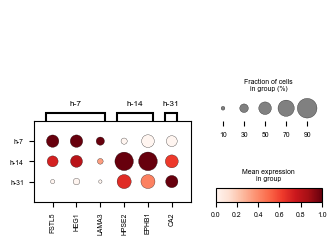

In [19]:
markers_GM_STR_clusters= {}
markers_GM_STR_clusters['h-7'] = ['FSTL5', 'HEG1', 'LAMA3']
markers_GM_STR_clusters['h-14'] = ['HPSE2', 'EPHB1']
markers_GM_STR_clusters['h-31'] = ['CA2']

adata_GM_STR = adata_spatial_astro[adata_spatial_astro.obs['SubGroup'].isin(['GM STR']), :].copy()

dot_GM_STR_curated = sc.pl.dotplot(
    adata_GM_STR, 
    markers_GM_STR_clusters, 
    groupby='Cluster', 
    layer='log2cpt', 
    return_fig=True,
    standard_scale="var",
    swap_axes=False,
)
dot_GM_STR_curated.savefig(os.path.join(output_fig_dir, 'dotplot_GM_STR_cluster_markers_curated.png'), dpi=300)
plt.show()
dot_GM_STR_curated.savefig(os.path.join(output_fig_dir, 'dotplot_GM_STR_cluster_markers_curated.pdf'))

dot_GM_STR_curated = sc.pl.dotplot(
    adata_GM_STR, 
    markers_GM_STR_clusters, 
    groupby='Cluster', 
    layer='log2cpt', 
    return_fig=True,
    standard_scale="var",
    swap_axes=True,
)
dot_GM_STR_curated.savefig(os.path.join(output_fig_dir, 'dotplot_GM_STR_cluster_markers_curated_swapaxes.png'), dpi=300)
dot_GM_STR_curated.savefig(os.path.join(output_fig_dir, 'dotplot_GM_STR_cluster_markers_curated_swapaxes.pdf'))
plt.close('all')

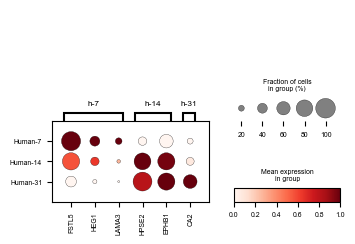

In [20]:
adata_GM_STR_rnaseq = adata_rnaseq_selfmap[adata_rnaseq_selfmap.obs['subGroup'].isin(['GM STR']), :].copy()
dot_GM_STR_curated = sc.pl.dotplot(
    adata_GM_STR_rnaseq, 
    markers_GM_STR_clusters, 
    groupby='Cluster', 
    return_fig=True,
    standard_scale="var",
    swap_axes=False,
)
dot_GM_STR_curated.savefig(os.path.join(output_fig_dir, 'dotplot_GM_STR_cluster_markers_curated_rnaseq.png'), dpi=300)
plt.show()
dot_GM_STR_curated.savefig(os.path.join(output_fig_dir, 'dotplot_GM_STR_cluster_markers_curated_rnaseq.pdf'))
plt.close()

### GM exSTR clusters

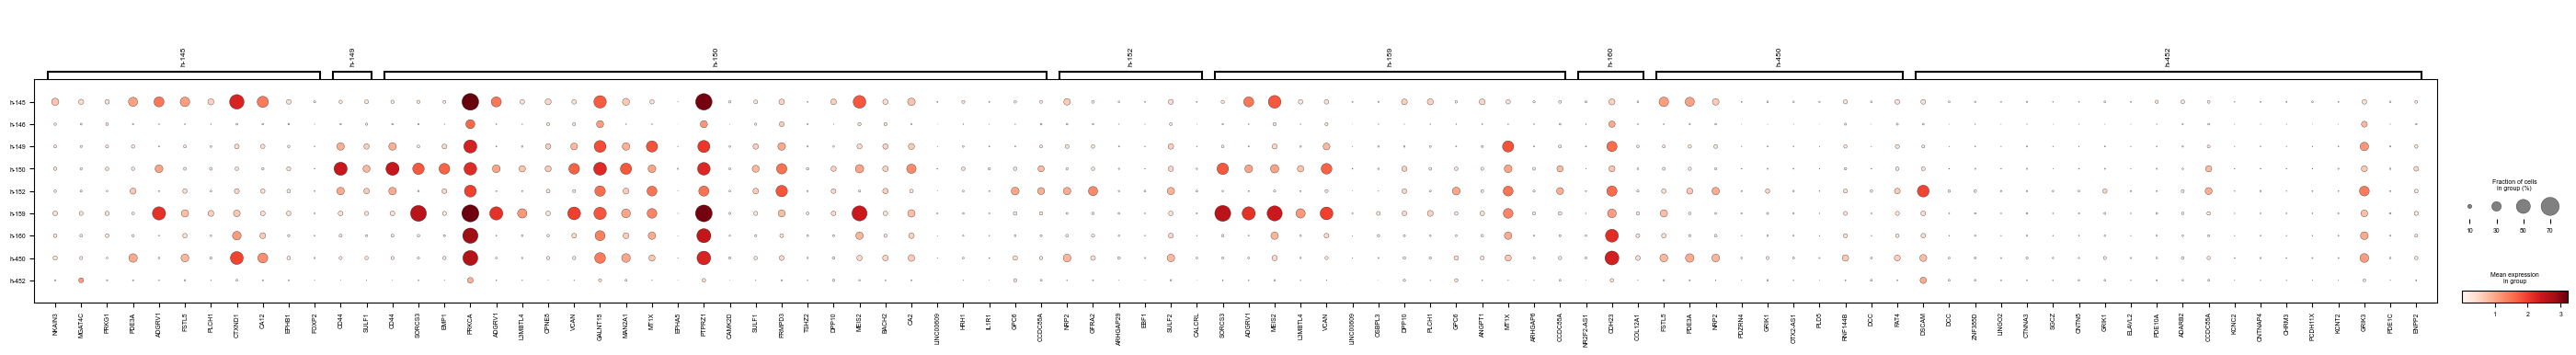

In [21]:
adata_GM_exSTR = adata_spatial_astro[adata_spatial_astro.obs['SubGroup'].isin(['GM exSTR']), :].copy()

# cluster: multiple gene values
gm_exstr_degs = cluster_degs_overlap[cluster_degs_overlap['subgroup_y'] == 'GM exSTR'].copy().reset_index(drop=True)
markers = gm_exstr_degs.groupby('cluster')['gene'].apply(list).to_dict()

dot_GM_STR = sc.pl.dotplot(adata_GM_exSTR, markers, groupby='Cluster', layer='log2cpt', return_fig=True)
dot_GM_STR.savefig(os.path.join(output_fig_dir, 'dotplot_GM_exSTR_markers_all.png'), dpi=300)
plt.show()
dot_GM_STR.savefig(os.path.join(output_fig_dir, 'dotplot_GM_exSTR_markers_all.pdf'))
plt.close()

In [22]:
adata_GM_exSTR.obs['Cluster'].unique()

['h-145', 'h-160', 'h-450', 'h-146', 'h-159', 'h-150', 'h-452', 'h-149', 'h-152']
Categories (9, object): ['h-145', 'h-146', 'h-149', 'h-150', ..., 'h-159', 'h-160', 'h-450', 'h-452']

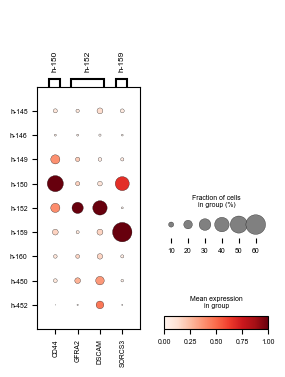

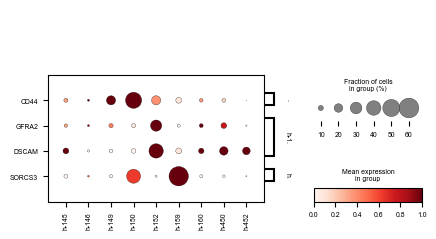

In [23]:
markers_GM_exSTR_clusters= {}
# markers_GM_exSTR_clusters['h-145'] = ['NKAIN3',]
markers_GM_exSTR_clusters['h-150'] = ['CD44']
markers_GM_exSTR_clusters['h-152'] = ['GFRA2', 'DSCAM']
markers_GM_exSTR_clusters['h-159'] = ['SORCS3']
# markers_GM_exSTR_clusters['h-452'] = ['PTPRZ1', 'PRKCA']

dot_GM_exSTR_curated = sc.pl.dotplot(
    adata_GM_exSTR, 
    markers_GM_exSTR_clusters, 
    groupby='Cluster', 
    layer='log2cpt', 
    return_fig=True,
    standard_scale="var",
    swap_axes=False,
)
dot_GM_exSTR_curated.savefig(os.path.join(output_fig_dir, 'dotplot_GM_exSTR_cluster_markers_curated.png'), dpi=300)
plt.show()
dot_GM_exSTR_curated.savefig(os.path.join(output_fig_dir, 'dotplot_GM_exSTR_cluster_markers_curated.pdf'))
plt.close()

dot_GM_exSTR_curated = sc.pl.dotplot(
    adata_GM_exSTR, 
    markers_GM_exSTR_clusters, 
    groupby='Cluster', 
    layer='log2cpt', 
    return_fig=True,
    standard_scale="var",
    swap_axes=True,
)
dot_GM_exSTR_curated.savefig(os.path.join(output_fig_dir, 'dotplot_GM_exSTR_cluster_markers_curated_swapaxes.png'), dpi=300)
plt.show()
dot_GM_exSTR_curated.savefig(os.path.join(output_fig_dir, 'dotplot_GM_exSTR_cluster_markers_curated_swapaxes.pdf'))
plt.close()

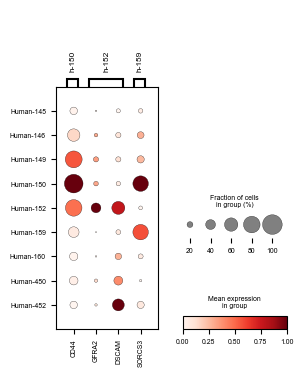

In [24]:
dot_GM_exSTR_curated_rnaseq = sc.pl.dotplot(
    adata_rnaseq_selfmap[adata_rnaseq_selfmap.obs['subGroup'] == 'GM exSTR', :], 
    markers_GM_exSTR_clusters, 
    groupby='Cluster', 
    return_fig=True,
    standard_scale="var",
    swap_axes=False,
)
dot_GM_exSTR_curated_rnaseq.savefig(os.path.join(output_fig_dir, 'dotplot_GM_exSTR_cluster_markers_curated_rnaseq.png'), dpi=300)
plt.show()
dot_GM_exSTR_curated_rnaseq.savefig(os.path.join(output_fig_dir, 'dotplot_GM_exSTR_cluster_markers_curated_rnaseq.pdf'))
plt.close()

### WM clusters

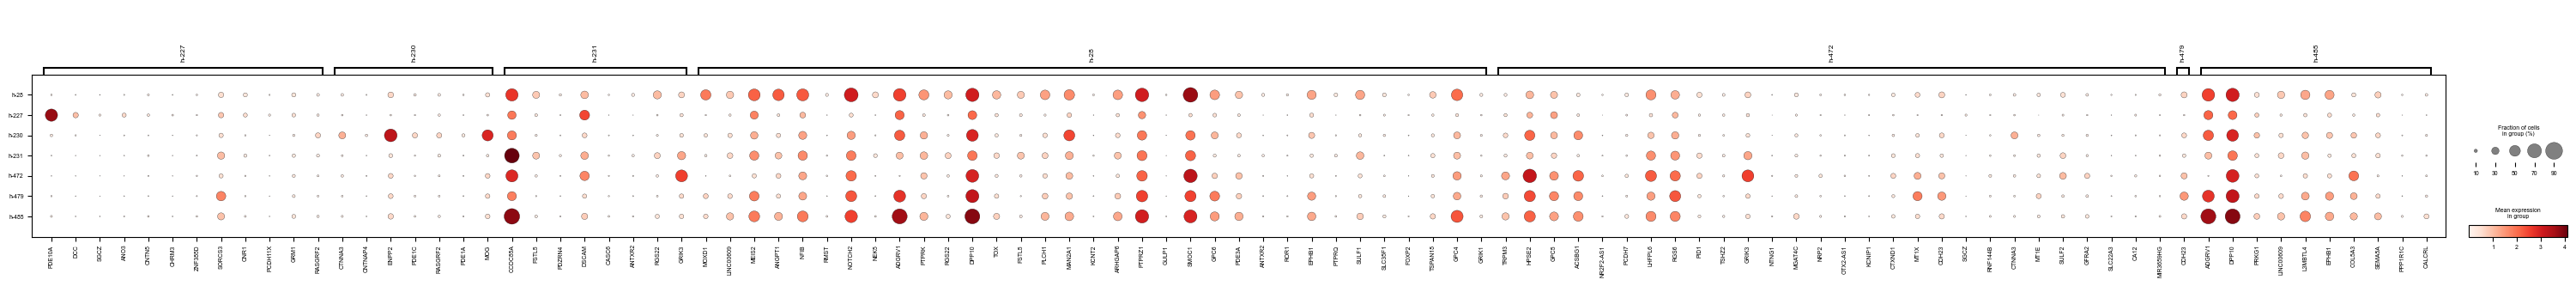

In [25]:
adata_WM = adata_spatial_astro[adata_spatial_astro.obs['SubGroup'].isin(['WM']), :].copy()

wm_degs = cluster_degs_overlap[cluster_degs_overlap['subgroup_y'] == 'WM'].copy().reset_index(drop=True)
markers = wm_degs.groupby('cluster')['gene'].apply(list).to_dict()

dot_WM = sc.pl.dotplot(adata_WM, markers, groupby='Cluster', layer='log2cpt', return_fig=True)
dot_WM.savefig(os.path.join(output_fig_dir, 'dotplot_WM_markers_all.png'), dpi=300)
plt.show()
dot_WM.savefig(os.path.join(output_fig_dir, 'dotplot_WM_markers_all.pdf'))
plt.close()

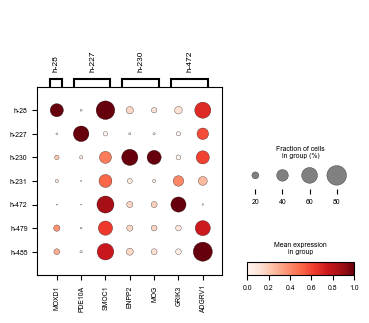

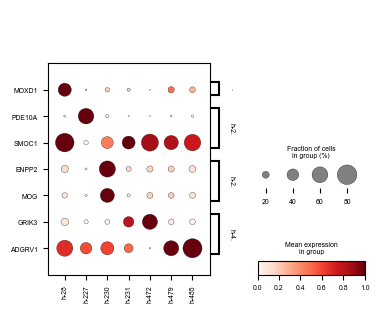

In [26]:
markers_WM_clusters= {}
markers_WM_clusters['h-28'] = ['MOXD1']
markers_WM_clusters['h-227'] = ['PDE10A', 'SMOC1']
markers_WM_clusters['h-230'] = ['ENPP2', 'MOG']
markers_WM_clusters['h-472'] = ['GRIK3','ADGRV1']
# markers_WM_clusters['h-485'] = []

dot_WM_curated = sc.pl.dotplot(
    adata_WM, 
    markers_WM_clusters, 
    groupby='Cluster', 
    layer='log2cpt', 
    return_fig=True,
    standard_scale="var",
    swap_axes=False
)
dot_WM_curated.savefig(os.path.join(output_fig_dir, 'dotplot_WM_cluster_markers_curated.png'), dpi=300)
plt.show()
dot_WM_curated.savefig(os.path.join(output_fig_dir, 'dotplot_WM_cluster_markers_curated.pdf'))
plt.close()

dot_WM_curated = sc.pl.dotplot(
    adata_WM, 
    markers_WM_clusters, 
    groupby='Cluster', 
    layer='log2cpt', 
    return_fig=True,
    standard_scale="var",
    swap_axes=True
)
dot_WM_curated.savefig(os.path.join(output_fig_dir, 'dotplot_WM_cluster_markers_curated_swapaxes.png'), dpi=300)
plt.show()
dot_WM_curated.savefig(os.path.join(output_fig_dir, 'dotplot_WM_cluster_markers_curated_swapaxes.pdf'))
plt.close()

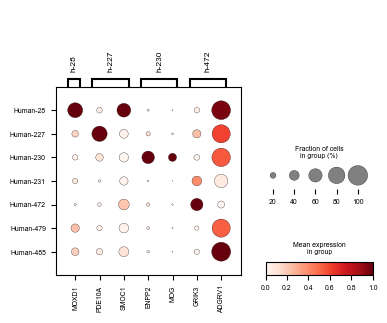

In [27]:
dot_WM_curated_rnaseq = sc.pl.dotplot(
    adata_rnaseq_selfmap[adata_rnaseq_selfmap.obs['subGroup'] == 'WM', :], 
    markers_WM_clusters, 
    groupby='Cluster', 
    return_fig=True,
    standard_scale="var",
    swap_axes=False,
)
dot_WM_curated_rnaseq.savefig(os.path.join(output_fig_dir, 'dotplot_WM_cluster_markers_curated_rnaseq.png'), dpi=300)
plt.show()
dot_WM_curated_rnaseq.savefig(os.path.join(output_fig_dir, 'dotplot_WM_cluster_markers_curated_rnaseq.pdf'))
plt.close()